<a id="summary"></a>

## Notebook 2 — Transactions EDA & monthly aggregates (`transactions_raw`)

**v1.** This notebook builds the time-based transaction view that later notebooks reuse for cohort retention, RFM scoring, and unit economics.

### How this notebook is organized

**Jump to parts:** [Part 1 — data loading](#part-1) · [Part 2 — monthly aggregates (pre-work)](#part-2) · [Part 3 — first business question](#part-3)

**Part 1 — data loading**

1. [Load `transactions_raw` joined with `customers_raw`](#q1)
2. [Prepare date buckets (transaction month)](#q2)

**Part 2 — monthly aggregates (pre-work for next steps)**

3. [Build per-customer, per-month aggregates](#q3)

**Part 3 — first business question**

4. [`Q6`: Who are our most valuable customers right now?](#q6)

---

### Objectives

- Create a clean transaction-month dataset tied to customer attributes (acquisition channel, segment).
- Prepare the aggregations needed for cohort analysis and behavioral intelligence.

### Scope

- Inputs: `transactions_raw` joined with `customers_raw`.
- Uses only **completed** transactions.
- Does **not** compute RFM/LTV/churn yet (that starts in later notebooks).

### Business Questions (from the project roadmap)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments?

### Expected output

- `df_tx` joined dataset (transactions + customer attributes) and the first answer table for the "most valuable customers right now" question.


In [1]:
# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")


In [14]:
# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

# Customers (attributes we will join onto transactions)
sql_customers = text("""
SELECT
  customer_id,
  acquisition_channel,
  acquisition_cost,
  registration_date,
  true_segment
FROM public.customers_raw
""")

df_customers = pd.read_sql(sql_customers, engine)

# Transactions (time series). We keep only completed events for clean spend.
sql_transactions = text("""
SELECT
  transaction_id,
  customer_id,
  transaction_datetime,
  amount,
  channel,
  status
FROM public.transactions_raw
WHERE status = 'completed'
""")

df_transactions = pd.read_sql(sql_transactions, engine)


In [15]:
df_customers.head()

,customer_id,acquisition_channel,acquisition_cost,registration_date,true_segment
0,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,referral,174.47,2026-01-30 00:00:00+00:00,high_value_active
1,60f6e3c6-3743-440b-bcdd-ff1603f78f95,paid_ads,220.42,2025-12-22 00:00:00+00:00,high_value_active
2,fb711018-ccba-47a2-9266-0136669adcb3,referral,201.70,2024-12-02 00:00:00+00:00,high_value_active
3,14c32f3e-420c-4076-95ec-5fb103b9c59d,organic,218.01,2024-04-28 00:00:00+00:00,high_value_active
4,94c8d245-fe90-45dc-874a-c3c0bfa9b873,referral,123.51,2026-01-16 00:00:00+00:00,high_value_active


In [16]:
df_transactions.head()

,transaction_id,customer_id,transaction_datetime,amount,channel,status
0,7b52751b-dfc2-400e-86d0-4132d4c0b369,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,7.30,in_app,completed
1,a439b95d-6536-46a3-9f25-e4e2e30d26aa,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-02-20 18:09:59.953338+00:00,218.44,card_present,completed
2,9947ed8a-d352-4931-bfde-2a0edfe3db14,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,349.11,online,completed
3,6a7f1c3f-c876-45a4-9d90-9956574a809d,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-02-25 01:32:28.322737+00:00,192.40,in_app,completed
4,7aeb8b20-6a1f-444d-b4ce-14a10bf92560,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,143.88,card_present,completed


In [17]:
print("df_customers:", df_customers.shape)
print("df_transactions (completed):", df_transactions.shape)


df_customers: (8000, 5)
df_transactions (completed): (1196165, 6)


In [29]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")

In [30]:
# Bucket transactions into month-level periods (for monthly aggregates)
# Pandas warns if we convert a timezone-aware datetime to Period; we drop tz explicitly.
txn_dt = df_tx["transaction_datetime"]
rxn_dt = df_tx["registration_date"]
# Newer pandas warns that is_datetime64tz_dtype is deprecated.
# We check the dtype using pandas' DatetimeTZDtype instead.
if isinstance(txn_dt.dtype, pd.DatetimeTZDtype):
    txn_dt = txn_dt.dt.tz_convert("UTC").dt.tz_localize(None)
if isinstance(rxn_dt.dtype, pd.DatetimeTZDtype):
    rxn_dt = rxn_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = (
    txn_dt.dt.to_period("M").dt.to_timestamp()
)
df_tx["registration_date"] = (
    rxn_dt.dt.to_period("M").dt.to_timestamp()
)

# Ensure numeric types
df_tx["amount"] = df_tx["amount"].astype(float)

print("df_tx (joined):", df_tx.shape)
df_tx.head()

df_tx (joined): (1196165, 11)


,transaction_id,customer_id,transaction_datetime,amount,channel,status,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month
0,7b52751b-dfc2-400e-86d0-4132d4c0b369,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,7.30,in_app,completed,referral,174.47,2026-01-01,high_value_active,2026-03-01
1,a439b95d-6536-46a3-9f25-e4e2e30d26aa,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-02-20 18:09:59.953338+00:00,218.44,card_present,completed,referral,174.47,2026-01-01,high_value_active,2026-02-01
2,9947ed8a-d352-4931-bfde-2a0edfe3db14,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,349.11,online,completed,referral,174.47,2026-01-01,high_value_active,2026-03-01
3,6a7f1c3f-c876-45a4-9d90-9956574a809d,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-02-25 01:32:28.322737+00:00,192.40,in_app,completed,referral,174.47,2026-01-01,high_value_active,2026-02-01
4,7aeb8b20-6a1f-444d-b4ce-14a10bf92560,460cf2eb-14a8-4373-8116-1a1aa1ae4a39,2026-03-01 00:00:00+00:00,143.88,card_present,completed,referral,174.47,2026-01-01,high_value_active,2026-03-01


,transaction_month,transaction_count
0,2024-03-01,1259
1,2024-04-01,2957
2,2024-05-01,4617
3,2024-06-01,6306
4,2024-07-01,8635
5,2024-08-01,10773
6,2024-09-01,13189
7,2024-10-01,16527
8,2024-11-01,19045
9,2024-12-01,23274


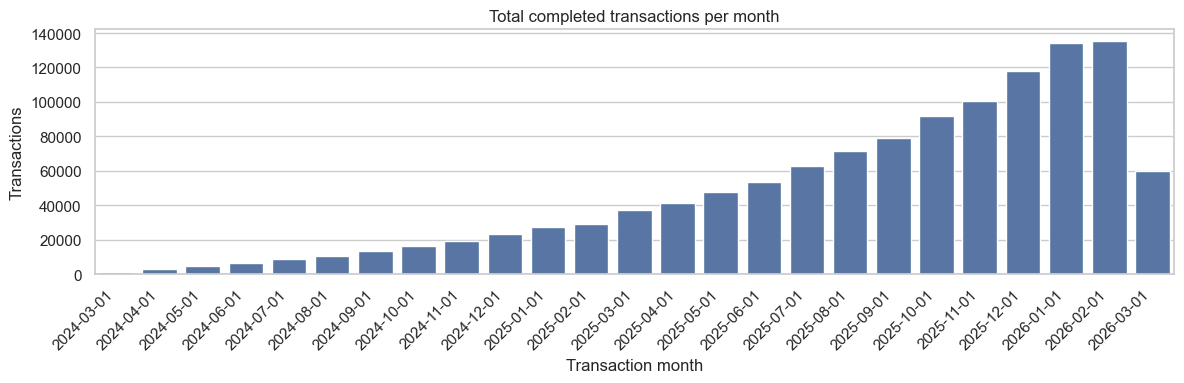

In [31]:
# Transactions per month (for monthly EDA / cohort pre-work)
monthly_tx_counts = (
    df_tx.groupby("transaction_month")
    .agg(transaction_count=("transaction_id", "count"))
    .reset_index()
    .sort_values("transaction_month")
)

display(monthly_tx_counts)

plt.figure(figsize=(12, 4))
ax = sns.barplot(
    data=monthly_tx_counts,
    x="transaction_month",
    y="transaction_count",
    color="#4C72B0",
)
ax.set_title("Total completed transactions per month")
ax.set_xlabel("Transaction month")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


As shown in the chart above, the number of transactions has been increasing over time, but the last month shows a sharp drop. This reflects the time window of our data-generation process; therefore, we should remove this month from our analysis for now.

In [32]:
# removing the last month from the analysis
df_tx = df_tx[df_tx["transaction_month"] != df_tx["transaction_month"].max()]
df_tx["transaction_month"].max()

Timestamp('2026-02-01 00:00:00')

In [ ]:
# Q6: Who are our most valuable customers right now?
# Definition for this first answer: "right now" = the latest available transaction month.

latest_month = df_tx["transaction_month"].max()
df_latest = df_tx[df_tx["transaction_month"] == latest_month].copy()

top_n = 10

monthly_value = (
    df_latest.groupby(
        ["customer_id", "acquisition_channel", "true_segment"],
        as_index=False,
    )
    .agg(
        monthly_transactions_count=("transaction_id", "count"),
        monthly_spent=("amount", "sum"),
    )
)

top_customers = monthly_value.sort_values("monthly_spent", ascending=False).head(top_n)

print(f"Latest transaction month in dataset: {latest_month:%Y-%m}")
print(f"Top {top_n} customers by monthly_spent (sum of completed transaction amounts):")
top_customers

# Quick interpretability: how segments/channels concentrate among the top spenders
segment_mix = top_customers["true_segment"].value_counts().reset_index()
segment_mix.columns = ["true_segment", "customers_in_top10"]

channel_mix = top_customers["acquisition_channel"].value_counts().reset_index()
channel_mix.columns = ["acquisition_channel", "customers_in_top10"]

print("\nSegment mix in the top spenders:")
display(segment_mix)

print("\nAcquisition channel mix in the top spenders:")
display(channel_mix)
